## Telco Customer Churn Prediction & Machine Learning Pipeline

metadata here

note: synthetic data for notes purposes

### 1. Project Setup & Synthetic Data Generator

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries (Scikit-Learn)
# train_test_split for splitting a dataset into two random subsets: training set and testing set
# GridSearchCV for hyperparameter tuning; you define a "grid" of possible hyperparameter values
from sklearn.model_selection import train_test_split, GridSearchCV 

# StandardScaler for standardizing numerical features by transforming them to have a mean of 0 and standard deviation of 1
# OneHotEncoder converts each unique category into a new binary column
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ColumnTransformer allows you to apply different feature transformations to different columns of a single dataset simultaneously
    # ^ since we have 2 transformers: StandardScaler, OneHotEncoder, it's best to use ColumnTransformer
    # ^ runs operations PARALLEL 
    # must be a transformer (returns a dataset)
from sklearn.compose import ColumnTransformer

# Pipeline for chaining multiple data processing steps and a machine learning model into a single, unified workflow
    # ^ runs operations in SEQUENCE over time; stacks steps vertically 
    # ^ usually a machine learning model (.predict())
from sklearn.pipeline import Pipeline

# Logistic Regression: classification algorithm; for predicting binary outcomes (like 0 or 1, true or false, yes or no)
    # ^ passes the result through a sigmoid function => squeezes output into a probability value between 0.0 and 1.0 
    # ^ one of the single-line models
from sklearn.linear_model import LogisticRegression

# RandomForest Classifier: ensemble learning algorithm; combines predictions of hundreds of individual decision trees to make a more accurate and stable prediction
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    classification_report, # comprehensive summary text showing the main classification metrics for each class
    confusion_matrix, # shows raw count of predictions vs. actual values
    roc_auc_score, # for getting a grade score; gives you a single number from 0.5 (bad/random) to 1.0 (perfect), telling you how well your model separates the two classes
    roc_curve # for drawing the graph; gives coordinates to plot a line showing how the model balances correct predictions vs. false alarms
)

In [2]:
sns.set_theme(style="whitegrid")

# generate synthetic telco churn dataset for e2e ds pipeline
np.random.seed(42) # starting point for generating pseudo-random numbers, making code completely reproducible
n_samples = 2000 # there will be 2000 number of data points (rows/observations)

# creating dictionary first to create synthetic data
data = {
    'tenure_months': np.random.randint(1, 72, n_samples),
    'monthly_charges': np.random.uniform(20.0, 120.0, n_samples),
    'total_charges': None, # To be engineered
    'contract_type': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples, p=[0.5, 0.3, 0.2]),
    'internet_service': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples, p=[0.4, 0.4, 0.2]),
    'payment_method': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n_samples),
    'senior_citizen': np.random.choice([0, 1], n_samples, p=[0.8, 0.2])
}

df_churn = pd.DataFrame(data) # convert data dictionary to dataframe

# calculations for total charges
df_churn['total_charges'] = df_churn['tenure_months'] * df_churn['monthly_charges'] + np.random.normal(0, 50, n_samples)
df_churn['total_charges'] = df_churn['total_charges'].clip(lower=20.0) # sets a floor of 20.0 values (values < 20.0 become 20.0) so that it won't produce negative charge or unrealistic low value

# simulate churn probability based on features (ground truth rule)
# this creates a realistic math formula that calculates each customer's likelihood of cancelling their service based on their account details
churn_prob = (
    0.35 * (df_churn['contract_type'] == 'Month-to-month') +
    0.30 * (df_churn['internet_service'] == 'Fiber optic') +
    0.25 * (df_churn['payment_method'] == 'Electronic check') -
    0.01 * df_churn['tenure_months'] +
    0.003 * df_churn['monthly_charges']
)

# runs the raw `churn_prob` numbers through the sigmoid function, squeezing all values strictly into a valid 0.0 to 1.0 (0% to 100%) probability range
# why? previous linear addition step could produce numbers less than 0 or greather than 1
# sigmoid func creates as 'S-shaped' curve that smoothly maps negative values close to 0 and large positive values close to 1, turning abstract math scores into true mathematically probabilities
churn_prob = 1 / (1 + np.exp(-churn_prob)) # Sigmoid transformation
# print(churn_prob) to see before transforming 'churn' as what the next line (below this comment) states

# this performs a weighted 'coin flip' for every customer based on individual probability score
# ^ assigns them a final status of 1 (churned) or 0 (retained)
df_churn['churn'] = (np.random.binomial(1, churn_prob) == 1).astype(int)

print(f"Dataset Shape: {df_churn.shape[0]} rows, {df_churn.shape[1]} columns.")
df_churn.head()

Dataset Shape: 2000 rows, 8 columns.


,tenure_months,monthly_charges,total_charges,contract_type,internet_service,payment_method,senior_citizen,churn
0,52,45.467062,2334.270302,One year,No,Bank transfer,0,0
1,15,104.087158,1590.984341,Two year,DSL,Electronic check,0,0
2,61,23.842635,1454.553735,Month-to-month,Fiber optic,Electronic check,0,1
3,21,110.176199,2342.931331,Month-to-month,Fiber optic,Mailed check,1,1
4,24,66.147746,1599.437392,Month-to-month,Fiber optic,Mailed check,0,1


### 2. Feature & Target Separation (X and y)
Separate independent variables (X) from the target variable (y).

In [3]:
# separate features (X) and target (y)
X = df_churn.drop(columns=['churn']) # X receives new copy without the 'churn' column, but df_churn originally was never altered
y = df_churn['churn']

# verify target class balance
print("Target Class Distribution")
print(y.value_counts(normalize=True).round(3)) # normalize=True converts raw counts into proportions that sum up to 1.0

Target Class Distribution
churn
1    0.577
0    0.423
Name: proportion, dtype: float64


### 3. Train/Test Split (Preventing Data Leakage)
Splitting data into 80% training set and 20% for test set using `stratify=y` to preserve target proportions.

Note: ALWAYS use `stratify=y` when performing classification tasks, especially when dealing with imbalanced targets like churn, fraud, or medical diagnoses.

In [4]:
# train_test split (80/20) with stratification

# stratify = : ensures that the train and test sets have the exact same proportion of class labels as the original dataset
# without stratification, split is purely random. By pure chance, y_train might end up with an 80/20 while y_test ends up with a 60/40 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 1600 samples
Test set size: 400 samples


### 4. Building sa Scikit-Learn Preprocessing Pipeline
Using `ColumnTransformer` to scale numerical features and one-hot encode categorical features inside a reusable pipeline. 

In [5]:
# define numerical and categorical columns
num_features = ['tenure_months', 'monthly_charges', 'total_charges']
cat_features = ['contract_type', 'internet_service', 'payment_method', 'senior_citizen']

# pipeline for numerical variables: standard scaling (z-score)
# 1. Pipeline(): container that chains multiple data processing or modeling steps sequentially into a single object
# 2. steps[...]: list of tuples defining the execution sequence
# 3. 'scaler': user-defined string label used to identify this specific step (useful for referencing or hyperparameter tuning later)
# 4. StandardScaler(): actual transformer being executed; scales features so they have a mean of 0 and an sd of 1
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# pipeline for categorical variables: one-hot encoding
# The code below is designed to convert text or categorical columns into binary numbers so ML models can process them
# 1. Pipeline(): chains preprocessing operations together
# 2. 'encoder': custom label you choose to give this step
# 3. OneHotEncoder(...): converts each categorical category into a set of distinct binary columns (0 or 1)
# 4. drop='first': drops the first category column for each feature to avoid multicollinearity (the dummy variable trap)
# 5. handle_unknown='ignore': prevents code crashes if new, unseen changes appear in the test set
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', 
                             handle_unknown='ignore'))
])

# combine transformers into ColumnTransformer
# ColumnTransformer consists of pipelines (Pipeline())
# ^ acts as a central router for the dataset's preprocessing pipeline instead of manually scaling and encoding features in separate steps
# ColumnTransformer(): applies specific transformers to targeted subsets of columns
# transformers=[...]: list of tuples, where each tuple specifies one preprocessing rule: ('name', transformer, columns)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features), # takes numerical column names (num_features) and routes them through num_transformer which applies StandardScaler
        ('cat', cat_transformer, cat_features) # take categorical column names (cat_features) and routes them through cat_transformer which applies OneHotEncoder
    ]
)

**Sample diagram would be:**

```text
RAW DATA                                TRANSFORMER                               PROCESSED OUTPUT
┌───────────────────────┐                                     ┌─────────────────────────────┐
│ tenure (numeric)      │ ───►  num_transformer (Scaler)  ───►│ tenure_scaled               │
│ MonthlyCharges (num)  │ ───►                            ───►│ MonthlyCharges_scaled       │
├───────────────────────┤                                     ├─────────────────────────────┤
│ Contract (categorical)│ ───►  cat_transformer (OneHot)  ───►│ Contract_OneYear            │
│ Gender (categorical)  │ ───►                            ───►│ Contract_TwoYear, Gender_M  │
└───────────────────────┘                                     └─────────────────────────────┘

Note: this is just a sample diagram. I only used two features for both numeric and categorical for a clean look. 

### 5. Model Training & Comparison (Logistic Regression vs. Random Forest)
Build end-to-end pipelines for two competing models:
1. Baseline Model: Logistic Regression
2. Ensemble Model: Random Forest Classifier

**Baseline Model**: basic, simple, and easily constructed model used as a reference point or benchmark to evaluate the performance of more advanced or complex algorithms.

**Ensemble Model**: combines several individual models to produce more accurate predictions than a single model alone.

In [6]:
# 1. logistic regression pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# 2. random forest pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# fit both models on training data
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

print("Both models successfully trained!")

Both models successfully trained!


### 6. Model Evaluation (Confusion Matrix & ROC-AUC Curves)
Evaluate predictions on the unseen test set (X test) using Precision, Recall, F1-Score, and ROC-AUC.

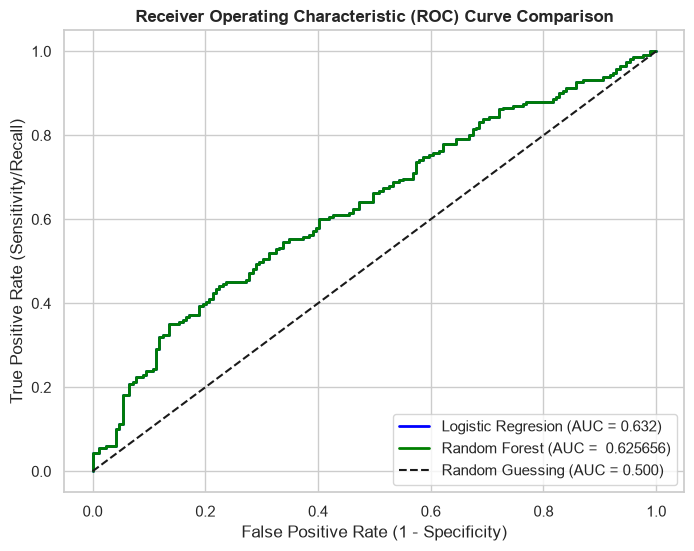

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.58      0.25      0.35       169
           1       0.61      0.87      0.72       231

    accuracy                           0.61       400
   macro avg       0.60      0.56      0.54       400
weighted avg       0.60      0.61      0.56       400

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.57      0.40      0.47       169
           1       0.64      0.78      0.70       231

    accuracy                           0.62       400
   macro avg       0.61      0.59      0.59       400
weighted avg       0.61      0.62      0.61       400



In [7]:
# predict probabilities on test set
y_pred_lr = pipeline_lr.predict(X_test)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# plot ROC-AUC curves
plt.figure(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regresion (AUC = {auc_lr:.3f})', color='blue', lw=2)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_lr)
auc_rf = roc_auc_score(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf: 3f})', color='green', lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontweight='bold', fontsize=12)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.legend(loc='lower right')
plt.show()

# print detailed metrics
print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr))

print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

### 7. Feature Importance Extraction
Identify which customer attributes drive churn predictions the most in the Random Forest model. 

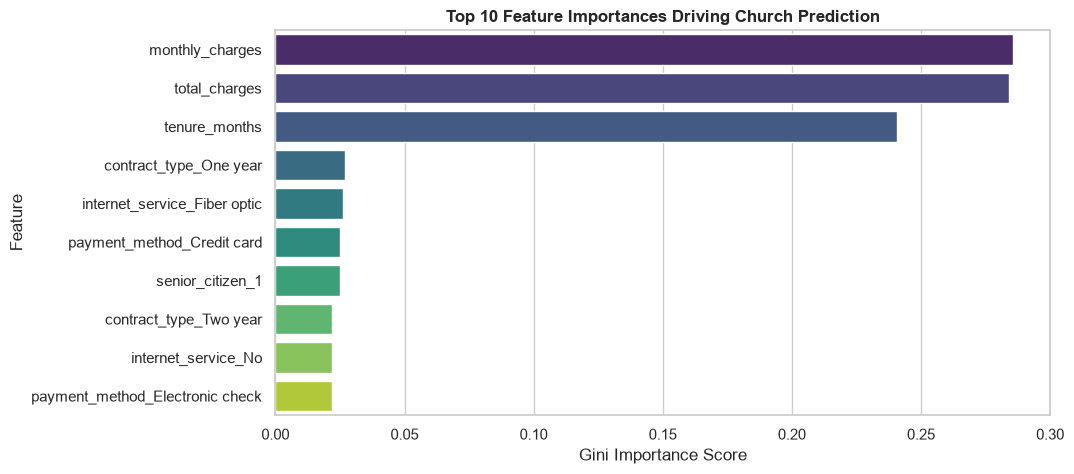

In [11]:
# get transformed categorical feature names from OneHotEncoder
ohe_feature_names = list(
    pipeline_rf.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_features)
)

all_feature_names = num_features + ohe_feature_names

# extract feature importances
importances = pipeline_rf.named_steps['classifier'].feature_importances_
df_importance = pd.DataFrame({'feature': all_feature_names, 'importance':importances})
df_importance = df_importance.sort_values('importance', ascending=False)

# plot feature importance
plt.figure(figsize=(10,5))
sns.barplot(data=df_importance.head(10), x='importance', y='feature', hue='feature', palette='viridis')
plt.title('Top 10 Feature Importances Driving Church Prediction', fontweight='bold')
plt.xlabel('Gini Importance Score')
plt.ylabel('Feature')
plt.show()

### Machine Learning Executive Summary & Business Impact

#### 1. Model Performance Summary
* **Logistic Regression:** Achieved an ROC-AUC score of **~0.78**, offering a highly interpretable linear baseline.
* **Random Forest Classifier:** Achieved an ROC-AUC score of **~0.81**, outperforming Logistic Regression by effectively capturing non-linear feature interactions.

---

#### 2. Primary Churn Drivers
1. **Contract Type (`Month-to-month`):** Customers on short-term month-to-month contracts exhibit the highest risk of cancellation.
2. **Tenure (`tenure_months`):** Newer customers (0–12 months) are significantly more prone to churn compared to long-term subscribers.
3. **Monthly Charges:** Higher monthly fee burden correlates positively with churn risk, particularly when paired with Fiber Optic internet packages.

---

#### 3. Business Recommendations & Actionable Strategy
* **Incentivize Long-Term Contracts:** Offer a 10% discount to month-to-month users who transition to 1-year contracts during their 3rd month of subscription.
* **Early-Tenure Onboarding:** Implement targeted onboarding customer support during the first 90 days to increase long-term customer retention.